In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("./data/train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **Exploratory Data Analysis**

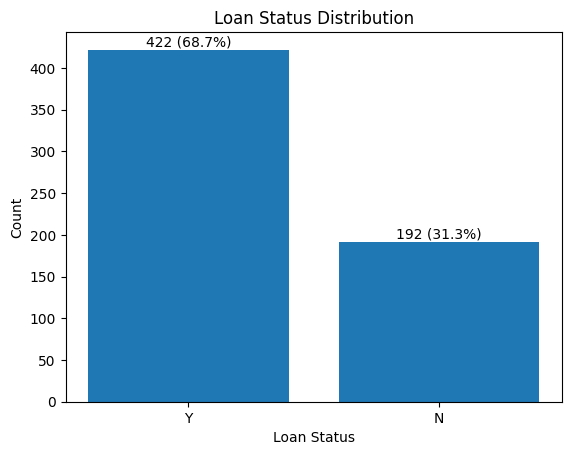

In [4]:
# Checking the distribution of target variable (loan_status)

counts = df['Loan_Status'].value_counts()

fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)

percentage_label = [f"{val} ({((val / counts.sum()) * 100):.1f}%)" for val in counts.values]
ax.bar_label(ax.containers[0], labels=percentage_label)

ax.set_title("Loan Status Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Count")
plt.show()

The dataset is unbalanced. Approved : 68.7% and Rejected : 31.3%

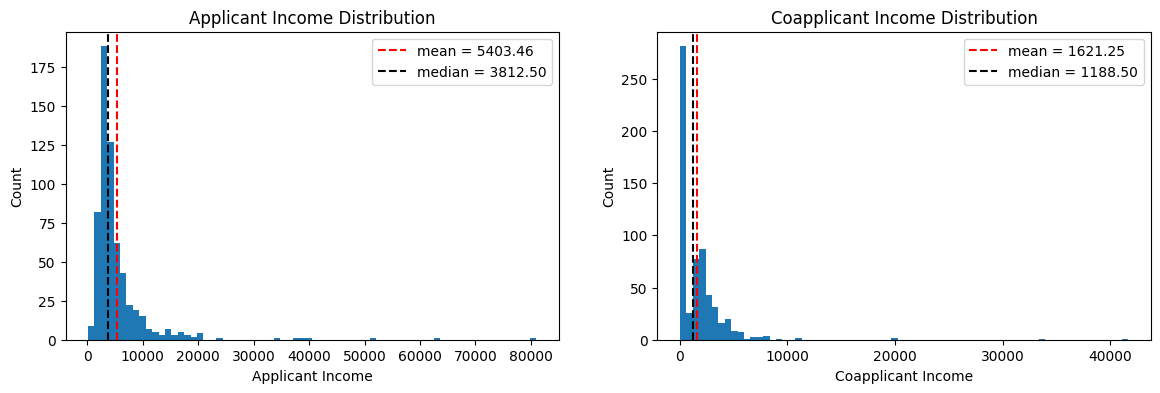

In [5]:
# checking the distribution of applicant income

applicant_mean = df['ApplicantIncome'].mean()
applicant_median = df['ApplicantIncome'].median()

coapplicant_mean = df['CoapplicantIncome'].mean()
coapplicant_median = df['CoapplicantIncome'].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(df['ApplicantIncome'], bins=70)
ax1.axvline(applicant_mean, color='red', linestyle='--', label=f'mean = {applicant_mean:.2f}')
ax1.axvline(applicant_median, color='black', linestyle='--', label=f'median = {applicant_median:.2f}')
ax1.legend()

ax1.set_title("Applicant Income Distribution")
ax1.set_xlabel("Applicant Income")
ax1.set_ylabel("Count")

ax2.hist(df['CoapplicantIncome'], bins=70)
ax2.axvline(coapplicant_mean, color='red', linestyle='--', label=f'mean = {coapplicant_mean:.2f}')
ax2.axvline(coapplicant_median, color='black', linestyle='--', label=f'median = {coapplicant_median:.2f}')
ax2.legend()

ax2.set_title("Coapplicant Income Distribution")
ax2.set_xlabel("Coapplicant Income")
ax2.set_ylabel("Count")

plt.show()


Both Applicant Income & Co-Applicant Income is right-skewed and have outliers. Additionally, Co-Applicant Income also have a zero spike.

<Axes: ylabel='Loan_Status'>

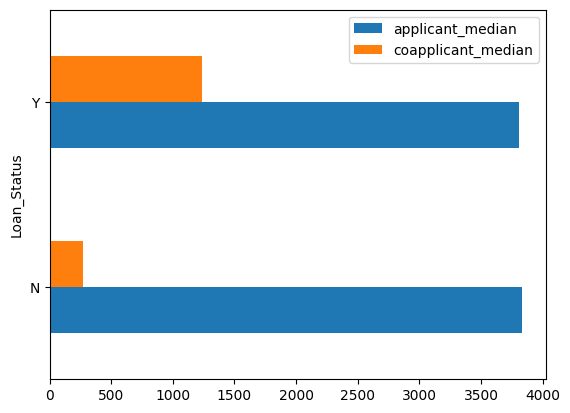

In [6]:
# Hypothesis : Coapplicant income plays a role in loan approval.

df.groupby('Loan_Status').agg(
    applicant_median = ('ApplicantIncome', 'median'),
    coapplicant_median = ('CoapplicantIncome', 'median')
).plot(kind='barh')

ApplicantIncome is more or less the same for everyone. 

Coapplicant Income is greater for the approved folks (Almost 5x) - Real Signal

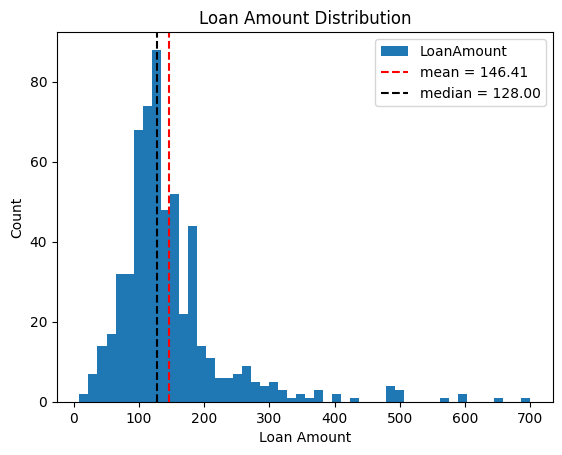

In [10]:
# Checking the distribution of loan amounts. 

loan_amount_mean = df['LoanAmount'].mean()
loan_amount_median = df['LoanAmount'].median()

ax = df['LoanAmount'].plot(kind='hist', bins=50)

ax.axvline(loan_amount_mean, color='red', linestyle='--', label=f'mean = {loan_amount_mean:.2f}')
ax.axvline(loan_amount_median, color='black', linestyle='--', label=f'median = {loan_amount_median:.2f}')
ax.legend()

ax.set_title("Loan Amount Distribution")
ax.set_xlabel("Loan Amount")
ax.set_ylabel("Count")

plt.show()

Loan Amount is also right-skewed and have outliers. 

[Text(0, 0, '129'), Text(0, 0, '126')]

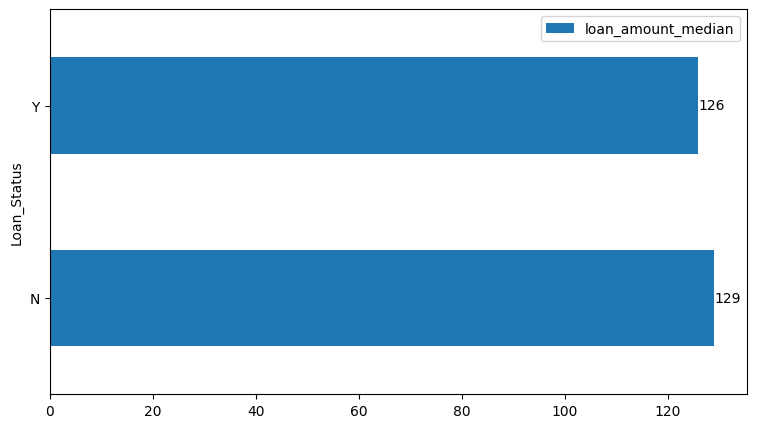

In [ ]:
#  Checking if loan amount plays a role in loan approval.

ax = df.groupby('Loan_Status').agg(
    loan_amount_median=('LoanAmount', 'median')
).plot(kind='barh', figsize=(9, 5))

ax.bar_label(ax.containers[0])

They are mostly similar and there is no signal in LoanAmount.

In [ ]:
# Approval rate by education
# Hypothesis: Education level may influence loan approval rates.

df.groupby('Education')['Loan_Status'].value_counts(normalize=True).unstack()



Loan_Status,N,Y
Education,,
Graduate,0.291667,0.708333
Not Graduate,0.388060,0.611940


Graduates tend to have 10% higher approval rates than Non-Graduate ones. 

In [ ]:
# Approval rate by credit history
# Hypothesis: Applicants with a good credit history are more likely to get their loans approved.

df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.204211,0.795789


There is a clear signal here. People with good credit 72% higher approval rates than one with bad credit score.

In [ ]:
# Approval rate by self-employed status
# Hypothesis: Self-employed applicants may have different approval rates compared to non-self-employed applicants.

df.groupby('Self_Employed')['Loan_Status'].value_counts(normalize=True).unstack()


Loan_Status,N,Y
Self_Employed,,
No,0.314000,0.686000
Yes,0.317073,0.682927


This column seems like it is barely matters. There is no signal here. As they both have 68% acceptance doesn't matter their employment.

In [ ]:
# Approval rate by Gender
# Hypothesis: Gender may influence loan approval rates.

df.groupby('Gender')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Gender,,
Female,0.330357,0.669643
Male,0.306748,0.693252


Male have 3% higher approval rates than Female. It's a very tiny gap. But worth noticing. 

In [ ]:
# Approval rate by Married status
# Hypothesis: Married applicants may have different approval rates compared to unmarried applicants.

df.groupby('Married')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Married,,
No,0.370892,0.629108
Yes,0.283920,0.716080


Married people have 9% higher approval rates than Unmarried. 

In [ ]:
# Approval rate by property area 
# Hypothesis: Semi-urban might have higher approval rates due it's potential to improve.

df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416


Semi-urban tend to have 16% higher approval rates than Rural and 11% higher approval rates than Urban.

But, the reason behind this is I'm not too sure. Let's dig into it.

In [ ]:
# Investigating the relationship between property area and other variables

df.groupby('Property_Area').agg(
    median_income=('ApplicantIncome', 'median'),
    median_loan_amount=('LoanAmount', 'median'),
    good_credit=('Credit_History', 'mean'),
    approval_rate=('Loan_Status', lambda x: (x == 'Y').mean()),
    count=('Loan_Status', 'count')
)

,median_income,median_loan_amount,good_credit,approval_rate,count
Property_Area,,,,,
Rural,3975.0,133.0,0.830303,0.614525,179
Semiurban,3859.0,127.5,0.861751,0.768240,233
Urban,3505.0,120.0,0.829670,0.658416,202


Rural has the highest income and lowest loan amount.

Semi-urban has higher good credit folks.

Honestly, it looks like the reason behind the property_area can't be finalized - Atleast with this data.

[Text(0, 0, '0.69'),
 Text(0, 0, '0.65'),
 Text(0, 0, '0.75'),
 Text(0, 0, '0.65')]

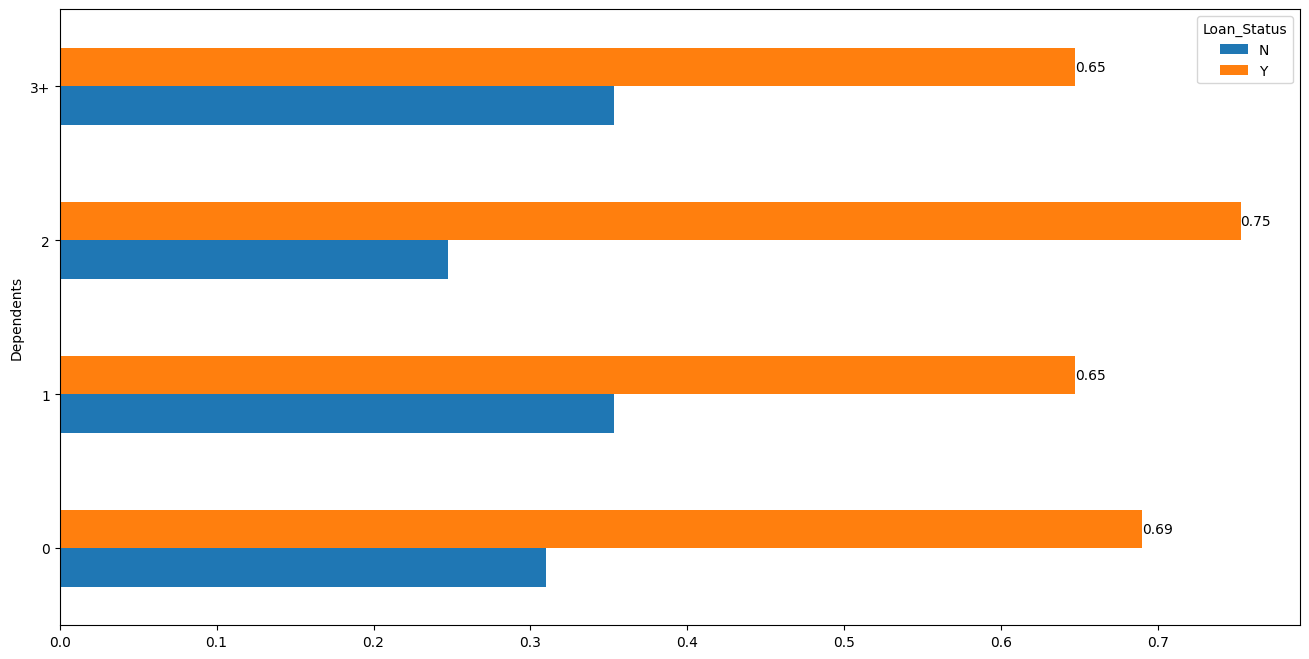

In [20]:
# Checking if dependents have an effect on loan approval rates.

ax = df.groupby('Dependents')['Loan_Status'].value_counts(normalize=True).unstack().plot(kind='barh', figsize=(16, 8))
ax.bar_label(ax.containers[1], fmt='%.2f')

There is non-monotic changes here. No signal on dependents

/var/folders/yf/2tdh9tj56hl3wlmxzd7y8s3c0000gn/T/ipykernel_82237/2927007614.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


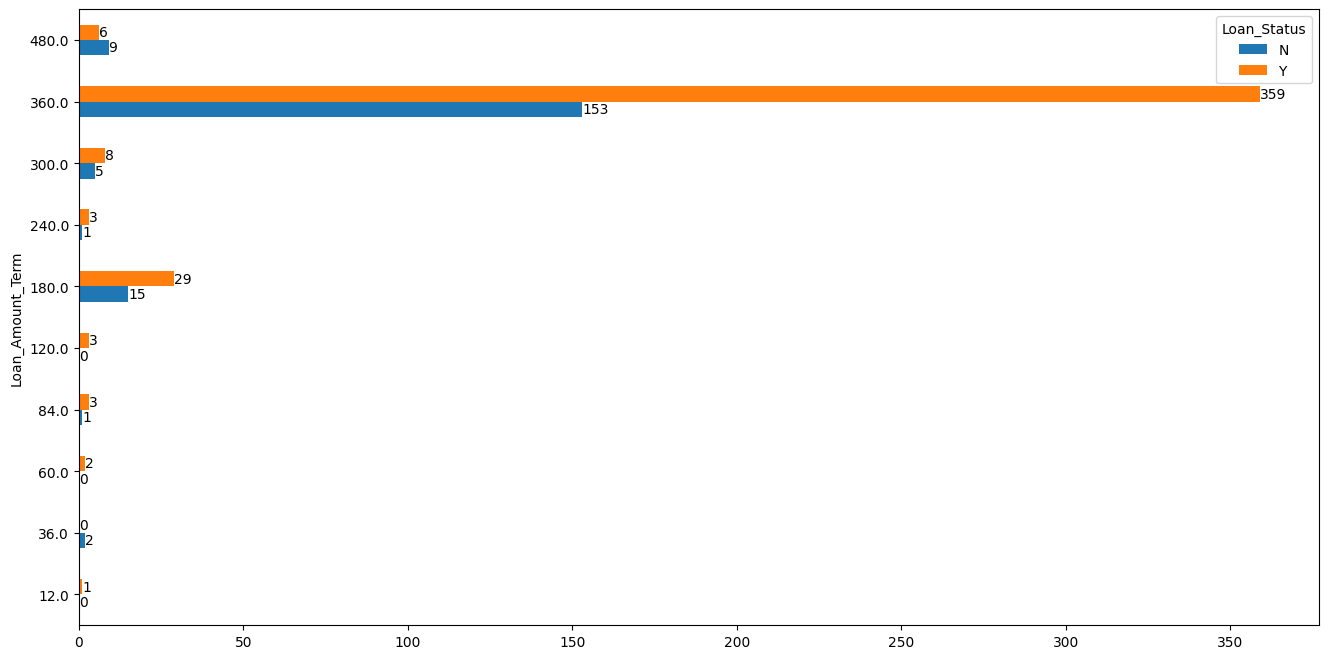

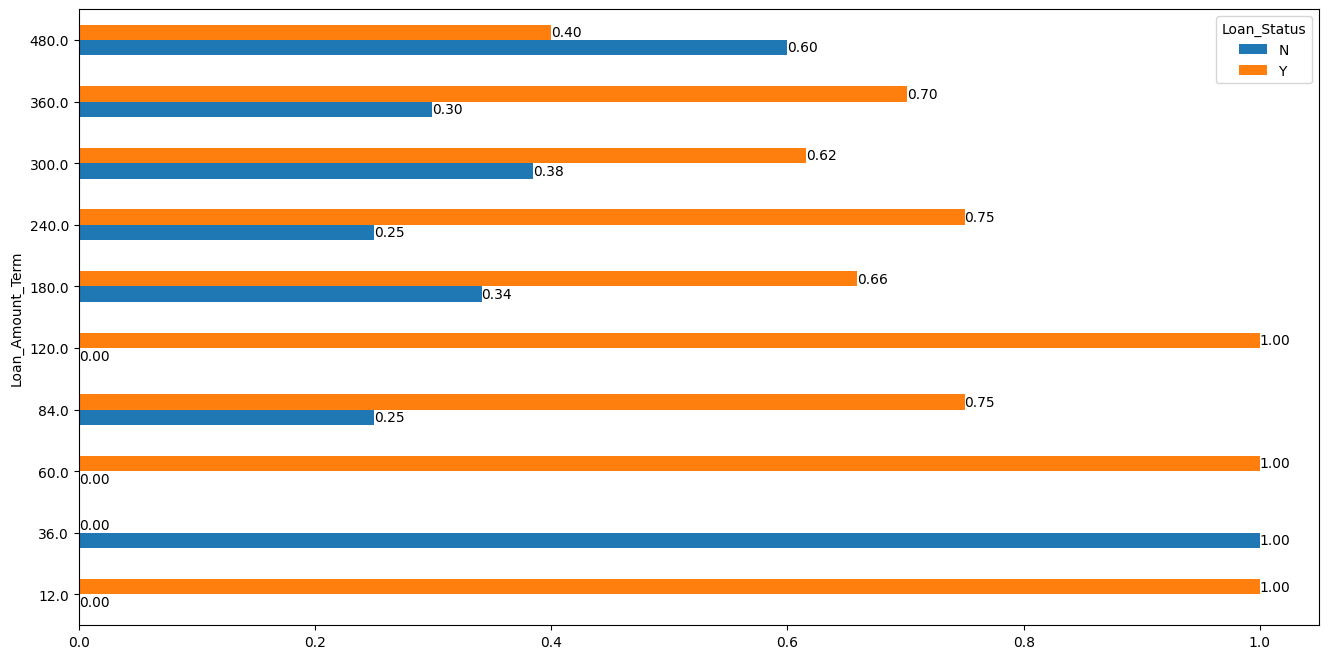

In [46]:
# Checking if loan_amount_term have any effect on loan approval rates.

ax1 = df.groupby('Loan_Amount_Term')['Loan_Status'].value_counts().unstack().plot(kind='barh', figsize=(16, 8))
ax1.bar_label(ax1.containers[0])
ax1.bar_label(ax1.containers[1])

ax2 = df.groupby('Loan_Amount_Term')['Loan_Status'].value_counts(normalize=True).unstack().plot(kind='barh', figsize=(16, 8))
ax2.bar_label(ax2.containers[0], fmt='%.2f')
ax2.bar_label(ax2.containers[1], fmt='%.2f')

plt.show()

No clear signal here to, just non-monotic changes.

# **EDA Report**

### **Categorical Features : approval-rate gap vs target**
| Feature | Effect on Approval | Strength |
|---|---|---|
| credit_history | Good 80% vs Bad 8% | 🟢 Dominant |
| property_area | Semiurban +11-15% over Urban/Rural | 🟢 Strong (cause unknown) |
| education | Graduate +10% | 🟡 Mild |
| married | Married +9% | 🟡 Mild |
| gender | Male +3% | 🔴 Weak |
| self_employed | Both groups ~68% (= base rate) | ⚫ No signal |
| dependents | 0/1/2/3+ all ≈ base rate, non-monotonic (69/65/75/65%) | ⚫ No signal |
| loan_amount_term | 83% are 360 (≈ base rate); off-360 rates are tiny-sample noise | ⚫ No signal (low variance) |

### **Numeric Features : median (approved Y vs rejected N)**
| Feature | Approved (Y) | Rejected (N) | Strength |
|---|---|---|---|
| coapplicant_income | 1239 | 268 | 🟢 Real signal (second earner helps) |
| applicant_income | 3812 | 3833 | ⚫ No signal alone |
| loan_amount | 126 | 129 | 🔴 Weak |
